In [43]:
import truststore
truststore.inject_into_ssl()

In [44]:
from dotenv import load_dotenv
load_dotenv()

True

In [45]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [46]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [47]:
def show_equation(state: QuadState):
    equation = f"{state['a']}x^2 + {state['b']}x + {state['c']}"
    return {"equation": equation}

In [48]:
def calculate_discriminant(state: QuadState):
    discriminant = state['b']**2 - 4*state['a']*state['c']
    return {"discriminant": discriminant}

In [49]:
def real_roots(state: QuadState):
    root1 = (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2*state['a'])
    result = f"The roots are {root1} and {root2}"

    return {"result": result}

In [50]:
def repeated_roots(state: QuadState):
    root = -state['b'] / (2*state['a'])
    result = f"The root is {root}"

    return {"result": result}

In [51]:
def no_real_roots(state: QuadState):
    return {"result": "There are no real roots"}

In [52]:
def check_condition(state: QuadState) -> Literal['real_roots', 'repeated_roots', 'no_real_roots']:
    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'repeated_roots'
    else:
        return 'no_real_roots'

In [53]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

In [54]:
initial_state = {'a': 4, 'b': -5, 'c': -4}
final_state = workflow.invoke(initial_state)
final_state

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x^2 + -5x + -4',
 'discriminant': 89,
 'result': 'The roots are 1.8042476415070754 and -0.5542476415070754'}

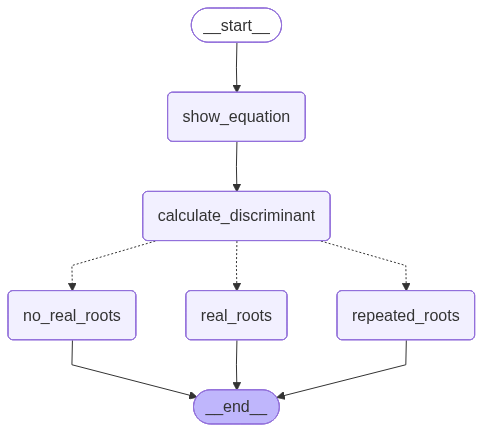

In [55]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [56]:
from pydantic import BaseModel, Field

In [57]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description='Sentiment of the review')

class DiagnosisSchema(BaseModel):
    issue_type: Literal['billing', 'technical', 'other'] = Field(description='Type of issue')
    urgency: Literal['low', 'medium', 'high'] = Field(description='Urgency of the issue')
    tone: Literal['calm', 'angry', 'frustrated'] = Field(description='Tone of the review')

In [58]:
from langchain_groq import ChatGroq
model = ChatGroq(model="llama-3.3-70b-versatile", temperature=1)
structured_model = model.with_structured_output(SentimentSchema)
structured_model_2 = model.with_structured_output(DiagnosisSchema)

In [59]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative']
    diagnosis: dict
    response: str

In [60]:
def find_sentiment(state: ReviewState):
    prompt = f"Review: {state['review']}\n\nWhat is the sentiment of this review? Respond with 'positive' or 'negative'."
    result = structured_model.invoke(prompt)
    return {"sentiment": result.sentiment}

def check_sentiment(state: ReviewState) -> Literal['positive_response', 'run_diagnostic']:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnostic'
    
def positive_response(state: ReviewState):
    prompt = f"Review: {state['review']}\n\nThe sentiment of this review is positive. Generate a positive response to this review."
    response = model.invoke(prompt).content
    return {"response": response}

def run_diagnostic(state: ReviewState):
    prompt = f"Review: {state['review']}\n\nThe sentiment of this review is negative. Diagnose the issues mentioned in this review and respond with a diagnosis in JSON format."
    diagnosis = structured_model_2.invoke(prompt)
    return {"diagnosis": diagnosis.model_dump()}

def negative_response(state: ReviewState):
    prompt = f"The user had a {state['diagnosis']['urgency']} urgency {state['diagnosis']['issue_type']} issue and their tone is {state['diagnosis']['tone']}. Generate an appropriate response to this review."
    response = model.invoke(prompt).content
    return {"response": response}

In [61]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnostic', run_diagnostic)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnostic', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

In [62]:
initial_state = {'review': "I had a terrible experience with your product. It stopped working after a week and customer service was unhelpful."}
final_state = workflow.invoke(initial_state)
final_state

{'review': 'I had a terrible experience with your product. It stopped working after a week and customer service was unhelpful.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'technical', 'urgency': 'high', 'tone': 'angry'},
 'response': '"I apologize for the frustration and inconvenience caused by the technical issue you\'re experiencing. I understand that this is a high-priority matter and I\'m committed to resolving it as quickly as possible. Can you please provide me with more details about the issue, such as any error messages or steps you\'ve taken so far? This will help me to better understand the problem and work towards a prompt solution. I appreciate your patience and cooperation, and I\'ll do my best to get this resolved for you ASAP."'}

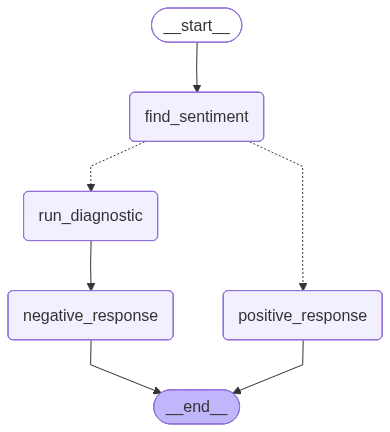

In [63]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())